In [2]:
import subprocess
import sys
def install(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    except:
        pass
packages = [
    "imbalanced-learn",
    "statsmodels",
    "pmdarima",
    "prophet",
    "openpyxl",
    "scipy"
]
for pkg in packages:
    install(pkg)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima
from prophet import Prophet
from scipy import stats
from datetime import datetime, timedelta

In [3]:
INPUT_PATH = "/content/Transformed_Dataset.xlsx"
COVID_CUTOFF_DATE = "2021-01-01"
FORECAST_HORIZON = 9
TEST_MONTHS = 3
CONFIDENCE_LEVEL = 0.95
# Class Imbalance Strategy
MIN_OBSERVATIONS = 24
INCLUDE_OTHER = False  # Exclude OTHER category
COMBINE_THRESHOLD = 0.05
# Stationarity Strategy
MAX_DIFF_ORDER = 2
STATIONARITY_SIGNIFICANCE = 0.05
APPLY_LOG_TRANSFORM = True

In [4]:
df_raw = pd.read_excel(INPUT_PATH)
df_raw.columns = df_raw.columns.str.strip()

In [5]:
# Clean and prepare
df_raw['MonthYear_dt'] = pd.to_datetime(df_raw['MonthYear'], format='%B %Y', errors='coerce')
df_raw = df_raw[~df_raw['MonthYear_dt'].isna()].copy()
df_raw['PatientVisits_Sum'] = pd.to_numeric(df_raw['PatientVisits_Sum'], errors='coerce')
df_raw = df_raw[~df_raw['PatientVisits_Sum'].isna()].copy()

In [6]:
# Filter post-COVID data
df = df_raw[df_raw['MonthYear_dt'] >= COVID_CUTOFF_DATE].copy()

In [7]:
# Analyze class distribution
class_distribution = df.groupby('type').agg({
    'PatientVisits_Sum': ['sum', 'count'],
    'MonthYear_dt': 'nunique'
}).reset_index()
class_distribution.columns = ['Drug_Type', 'Total_Visits', 'Records', 'Months']
class_distribution['Visit_%'] = (class_distribution['Total_Visits'] / class_distribution['Total_Visits'].sum() * 100).round(2)
class_distribution = class_distribution.sort_values('Total_Visits', ascending=False)

In [8]:
print(class_distribution.to_string(index=False))

      Drug_Type  Total_Visits  Records  Months  Visit_%
        GENERIC       1680142    45722      55    38.30
BRANDED GENERIC       1527595     6459      55    34.82
          BRAND       1059123    19303      55    24.14
          OTHER        103438    12801      55     2.36
          Other         16577     2480      55     0.38


In [9]:
# Filter to only Generic, Branded Generic, Branded
target_types = ['GENERIC', 'BRANDED GENERIC', 'BRAND']
df['type_clean'] = df['type'].str.upper().str.strip()
df = df[df['type_clean'].isin(target_types)].copy()

In [10]:
# Standardize names
df['type_clean'] = df['type_clean'].replace({
    'GENERIC': 'Generic',
    'BRANDED GENERIC': 'Branded Generic',
    'BRAND': 'Branded'
})

In [11]:
drug_types = df['type_clean'].unique().tolist()

In [12]:
# Aggregate time series
ts_data = df.groupby(['MonthYear_dt', 'type_clean'])['PatientVisits_Sum'].sum().reset_index()
ts_data = ts_data.pivot(index='MonthYear_dt', columns='type_clean', values='PatientVisits_Sum').fillna(0)

In [13]:
print(f"\n Time Series: {len(ts_data)} months, Types: {ts_data.columns.tolist()}")


 Time Series: 55 months, Types: ['Branded', 'Branded Generic', 'Generic']


In [14]:
def test_stationarity(series, name):
    "Comprehensive stationarity testing with ADF and KPSS"
    results = {}

    # ADF Test
    adf_result = adfuller(series.dropna(), autolag='AIC')
    results['ADF_Stat'] = adf_result[0]
    results['ADF_PValue'] = adf_result[1]
    results['ADF_Stationary'] = adf_result[1] < STATIONARITY_SIGNIFICANCE

    # KPSS Test
    try:
        kpss_result = kpss(series.dropna(), regression='ct', nlags='auto')
        results['KPSS_Stat'] = kpss_result[0]
        results['KPSS_PValue'] = kpss_result[1]
        results['KPSS_Stationary'] = kpss_result[1] > STATIONARITY_SIGNIFICANCE
    except:
        results['KPSS_Stat'] = np.nan
        results['KPSS_PValue'] = np.nan
        results['KPSS_Stationary'] = False

    # Conclusion
    if results['ADF_Stationary'] and results['KPSS_Stationary']:
        results['Conclusion'] = 'Stationary'
    elif not results['ADF_Stationary'] and not results['KPSS_Stationary']:
        results['Conclusion'] = 'Non-Stationary'
    else:
        results['Conclusion'] = 'Trend-Stationary'

    return results

In [15]:
def make_stationary(series, name):
    "Transform series to achieve stationarity"
    original = series.copy()
    transformations = []

    # Log transform
    if APPLY_LOG_TRANSFORM and (series > 0).all():
        series = np.log(series + 1)
        transformations.append('log')

    # Differencing
    diff_order = 0
    for d in range(1, MAX_DIFF_ORDER + 1):
        stationarity = test_stationarity(series, name)

        if stationarity['Conclusion'] == 'Stationary':
            break

        series = series.diff().dropna()
        diff_order = d
        transformations.append(f'diff_{d}')

    return series, transformations, diff_order

In [16]:
# Test original data
stationarity_results = []
transformed_series = {}

In [17]:
for col in ts_data.columns:
    series = ts_data[col].dropna()

    if len(series) < MIN_OBSERVATIONS:
        print(f"{col:<20} | {'N/A':<12} | {'N/A':<12} | {'Insufficient Data':<20}")
        continue

    results = test_stationarity(series, col)
    results['Drug_Type'] = col
    results['Original_Length'] = len(series)
    stationarity_results.append(results)

    status = ' Stationary' if results['Conclusion'] == 'Stationary' else ' Non-Stationary'
    print(f"{col:<20} | {results['ADF_PValue']:<12.4f} | {results['KPSS_PValue']:<12.4f} | {status:<20}")

stationarity_df = pd.DataFrame(stationarity_results)


Branded              | 0.6095       | 0.1000       |  Non-Stationary     
Branded Generic      | 0.6422       | 0.0100       |  Non-Stationary     
Generic              | 0.1499       | 0.0479       |  Non-Stationary     


In [18]:
# Apply transformations
print("\n Applying Transformations for Data Stationary:")


for col in ts_data.columns:
    series = ts_data[col].dropna()

    if len(series) < MIN_OBSERVATIONS:
        continue

    original_results = test_stationarity(series, col)

    if original_results['Conclusion'] != 'Stationary':
        transformed, transformations, diff_order = make_stationary(series, col)
        transformed_series[col] = {
            'original': series,
            'transformed': transformed,
            'transformations': transformations,
            'diff_order': diff_order
        }

        final_results = test_stationarity(transformed, col)

        print(f"\n{col}:")
        print(f"  Original: {original_results['Conclusion']}")
        print(f"  Transformations: {' → '.join(transformations)}")
        print(f"  Final: {final_results['Conclusion']}")
        print(f"  ADF p-value: {original_results['ADF_PValue']:.4f} → {final_results['ADF_PValue']:.4f}")
    else:
        transformed_series[col] = {
            'original': series,
            'transformed': series,
            'transformations': ['none'],
            'diff_order': 0
        }
        print(f"\n{col}: Already stationary ")


 Applying Transformations for Data Stationary:

Branded:
  Original: Trend-Stationary
  Transformations: log → diff_1 → diff_2
  Final: Trend-Stationary
  ADF p-value: 0.6095 → 0.0228

Branded Generic:
  Original: Non-Stationary
  Transformations: log → diff_1 → diff_2
  Final: Trend-Stationary
  ADF p-value: 0.6422 → 0.0000

Generic:
  Original: Non-Stationary
  Transformations: log → diff_1 → diff_2
  Final: Trend-Stationary
  ADF p-value: 0.1499 → 0.0000


In [19]:
# Forecasting SARIMA
def forecast_sarima_enhanced(train, test, forecast_periods, name, diff_order=0):
    try:
        model = auto_arima(
            train,
            start_p=0, max_p=3,
            start_q=0, max_q=3,
            d=diff_order,
            start_P=0, max_P=2,
            start_Q=0, max_Q=2,
            D=1 if len(train) >= 24 else 0,
            seasonal=True if len(train) >= 24 else False,
            m=12 if len(train) >= 24 else 1,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            trace=False,
            information_criterion='aicc',
            n_fits=50
        )

        forecast, conf_int = model.predict(n_periods=forecast_periods, return_conf_int=True)

        if test is not None and len(test) > 0:
            test_pred = model.predict(n_periods=len(test))
            mae = np.mean(np.abs(test.values - test_pred))
            rmse = np.sqrt(np.mean((test.values - test_pred)**2))
            mape = np.mean(np.abs((test.values - test_pred) / test.values)) * 100
        else:
            mae, rmse, mape = np.nan, np.nan, np.nan

        return {
            'forecast': forecast,
            'lower': conf_int[:, 0],
            'upper': conf_int[:, 1],
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'model': model,
            'success': True
        }
    except Exception as e:
        print(f" SARIMA failed: {str(e)}")
        return {'success': False}


In [20]:
# Forecasting Prophet
def forecast_prophet_enhanced(train, test, forecast_periods, name):
    try:
        train_df = pd.DataFrame({
            'ds': train.index,
            'y': train.values
        })

        model = Prophet(
            yearly_seasonality=True if len(train) >= 24 else False,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=0.05,
            interval_width=0.95,
            seasonality_prior_scale=10
        )

        model.fit(train_df)

        future = model.make_future_dataframe(periods=forecast_periods, freq='MS')
        forecast = model.predict(future)
        forecast_values = forecast.tail(forecast_periods)

        if test is not None and len(test) > 0:
            test_future = model.make_future_dataframe(periods=len(test), freq='MS')
            test_pred = model.predict(test_future).tail(len(test))['yhat'].values

            mae = np.mean(np.abs(test.values - test_pred))
            rmse = np.sqrt(np.mean((test.values - test_pred)**2))
            mape = np.mean(np.abs((test.values - test_pred) / test.values)) * 100
        else:
            mae, rmse, mape = np.nan, np.nan, np.nan

        return {
            'forecast': forecast_values['yhat'].values,
            'lower': forecast_values['yhat_lower'].values,
            'upper': forecast_values['yhat_upper'].values,
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'model': model,
            'success': True
        }
    except Exception as e:
        print(f" Prophet failed: {str(e)}")
        return {'success': False}


In [21]:
# Forecasting Exponential Smoothing
def forecast_exp_smoothing_enhanced(train, test, forecast_periods, name):
    try:
        if len(train) >= 24:
            model = ExponentialSmoothing(
                train,
                seasonal_periods=12,
                trend='add',
                seasonal='add',
                damped_trend=True
            ).fit(optimized=True, use_brute=True)
        else:
            model = ExponentialSmoothing(
                train,
                trend='add',
                seasonal=None,
                damped_trend=True
            ).fit(optimized=True)

        forecast = model.forecast(steps=forecast_periods)

        residuals = train - model.fittedvalues
        std_error = residuals.std()
        z_score = 1.96

        lower = forecast - z_score * std_error
        upper = forecast + z_score * std_error

        if test is not None and len(test) > 0:
            test_pred = model.forecast(steps=len(test))

            mae = np.mean(np.abs(test.values - test_pred.values))
            rmse = np.sqrt(np.mean((test.values - test_pred.values)**2))
            mape = np.mean(np.abs((test.values - test_pred.values) / test.values)) * 100
        else:
            mae, rmse, mape = np.nan, np.nan, np.nan

        return {
            'forecast': forecast.values,
            'lower': lower.values,
            'upper': upper.values,
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'model': model,
            'success': True
        }
    except Exception as e:
        print(f" Exp Smoothing failed: {str(e)}")
        return {'success': False}

In [22]:
all_results = []
forecast_data = {}
for drug_type in ts_data.columns:
    series = ts_data[drug_type].dropna()

    if len(series) < MIN_OBSERVATIONS:
        print(f"\n Skipping {drug_type}: Only {len(series)} months (need {MIN_OBSERVATIONS}+)")
        continue


    print(f"{drug_type}")


    train = series[:-TEST_MONTHS]
    test = series[-TEST_MONTHS:]

    print(f"  Training: {len(train)} months | Testing: {TEST_MONTHS} months")

    diff_order = transformed_series[drug_type]['diff_order'] if drug_type in transformed_series else 0

    # SARIMA
    print(f" SARIMA (d={diff_order})", end=" ")
    sarima_result = forecast_sarima_enhanced(train, test, FORECAST_HORIZON, drug_type, diff_order)
    if sarima_result['success']:
        print(f" MAPE: {sarima_result['mape']:.2f}%")
        all_results.append({
            'Drug_Type': drug_type,
            'Model': 'SARIMA',
            'MAE': sarima_result['mae'],
            'RMSE': sarima_result['rmse'],
            'MAPE': sarima_result['mape']
        })

    # Prophet
    print(f" Prophet", end=" ")
    prophet_result = forecast_prophet_enhanced(train, test, FORECAST_HORIZON, drug_type)
    if prophet_result['success']:
        print(f" MAPE: {prophet_result['mape']:.2f}%")
        all_results.append({
            'Drug_Type': drug_type,
            'Model': 'Prophet',
            'MAE': prophet_result['mae'],
            'RMSE': prophet_result['rmse'],
            'MAPE': prophet_result['mape']
        })

    # Exp Smoothing
    print(f" Exp Smoothing", end=" ")
    exp_result = forecast_exp_smoothing_enhanced(train, test, FORECAST_HORIZON, drug_type)
    if exp_result['success']:
        print(f" MAPE: {exp_result['mape']:.2f}%")
        all_results.append({
            'Drug_Type': drug_type,
            'Model': 'Exp_Smoothing',
            'MAE': exp_result['mae'],
            'RMSE': exp_result['rmse'],
            'MAPE': exp_result['mape']
        })

    forecast_data[drug_type] = {
        'train': train,
        'test': test,
        'sarima': sarima_result if sarima_result['success'] else None,
        'prophet': prophet_result if prophet_result['success'] else None,
        'exp_smoothing': exp_result if exp_result['success'] else None
    }

Branded
  Training: 52 months | Testing: 3 months
 SARIMA (d=2)  MAPE: 26.03%
 Prophet  MAPE: 19.70%
 Exp Smoothing  MAPE: 8.51%
Branded Generic
  Training: 52 months | Testing: 3 months
 SARIMA (d=2)  MAPE: 4.92%
 Prophet  MAPE: 11.51%
 Exp Smoothing  MAPE: 7.20%
Generic
  Training: 52 months | Testing: 3 months
 SARIMA (d=2)  MAPE: 9.36%
 Prophet  MAPE: 10.66%
 Exp Smoothing  MAPE: 3.07%


In [23]:
print(" Evaluation Metrics & Best Model Selection")
results_df = pd.DataFrame(all_results)
print(results_df.round(2).to_string(index=False))
best_models = results_df.loc[results_df.groupby('Drug_Type')['MAPE'].idxmin()]
print("\n Best Model Summary:")

best_summary = []
for _, row in best_models.iterrows():
    drug_type = row['Drug_Type']
    last_actual = ts_data[drug_type].iloc[-1]

    model_name = row['Model'].lower().replace('_smoothing', '_smoothing')
    model_result = forecast_data[drug_type][model_name]
    forecast_avg = np.mean(model_result['forecast'][:6])
    growth = ((forecast_avg - last_actual) / last_actual) * 100
    best_summary.append({
        'Drug_Type': drug_type,
        'Best_Model': row['Model'],
        'MAPE_%': row['MAPE'],
        'RMSE': row['RMSE'],
        'Last_Actual': int(last_actual),
        'Forecast_Avg': int(forecast_avg),
        'Growth_%': round(growth, 1),
        'Stationary': stationarity_df[stationarity_df['Drug_Type']==drug_type]['Conclusion'].values[0] if drug_type in stationarity_df['Drug_Type'].values else 'N/A'
    })
best_df = pd.DataFrame(best_summary)
print(best_df.to_string(index=False))

 Evaluation Metrics & Best Model Selection
      Drug_Type         Model     MAE    RMSE  MAPE
        Branded        SARIMA 3704.50 3759.71 26.03
        Branded       Prophet 2816.83 2918.74 19.70
        Branded Exp_Smoothing 1199.75 1458.13  8.51
Branded Generic        SARIMA 1163.71 1420.22  4.92
Branded Generic       Prophet 2682.07 2836.07 11.51
Branded Generic Exp_Smoothing 1682.38 2026.55  7.20
        Generic        SARIMA 3356.69 3584.04  9.36
        Generic       Prophet 3854.82 4008.76 10.66
        Generic Exp_Smoothing 1085.40 1458.68  3.07

 Best Model Summary:
      Drug_Type    Best_Model   MAPE_%        RMSE  Last_Actual  Forecast_Avg  Growth_%       Stationary
        Branded Exp_Smoothing 8.509243 1458.128562        14430         15513       7.5 Trend-Stationary
Branded Generic        SARIMA 4.916457 1420.216695        22816         24701       8.3   Non-Stationary
        Generic Exp_Smoothing 3.068652 1458.675996        35743         37153       3.9   Non-Statio

Visualizations

 Time Series Overview


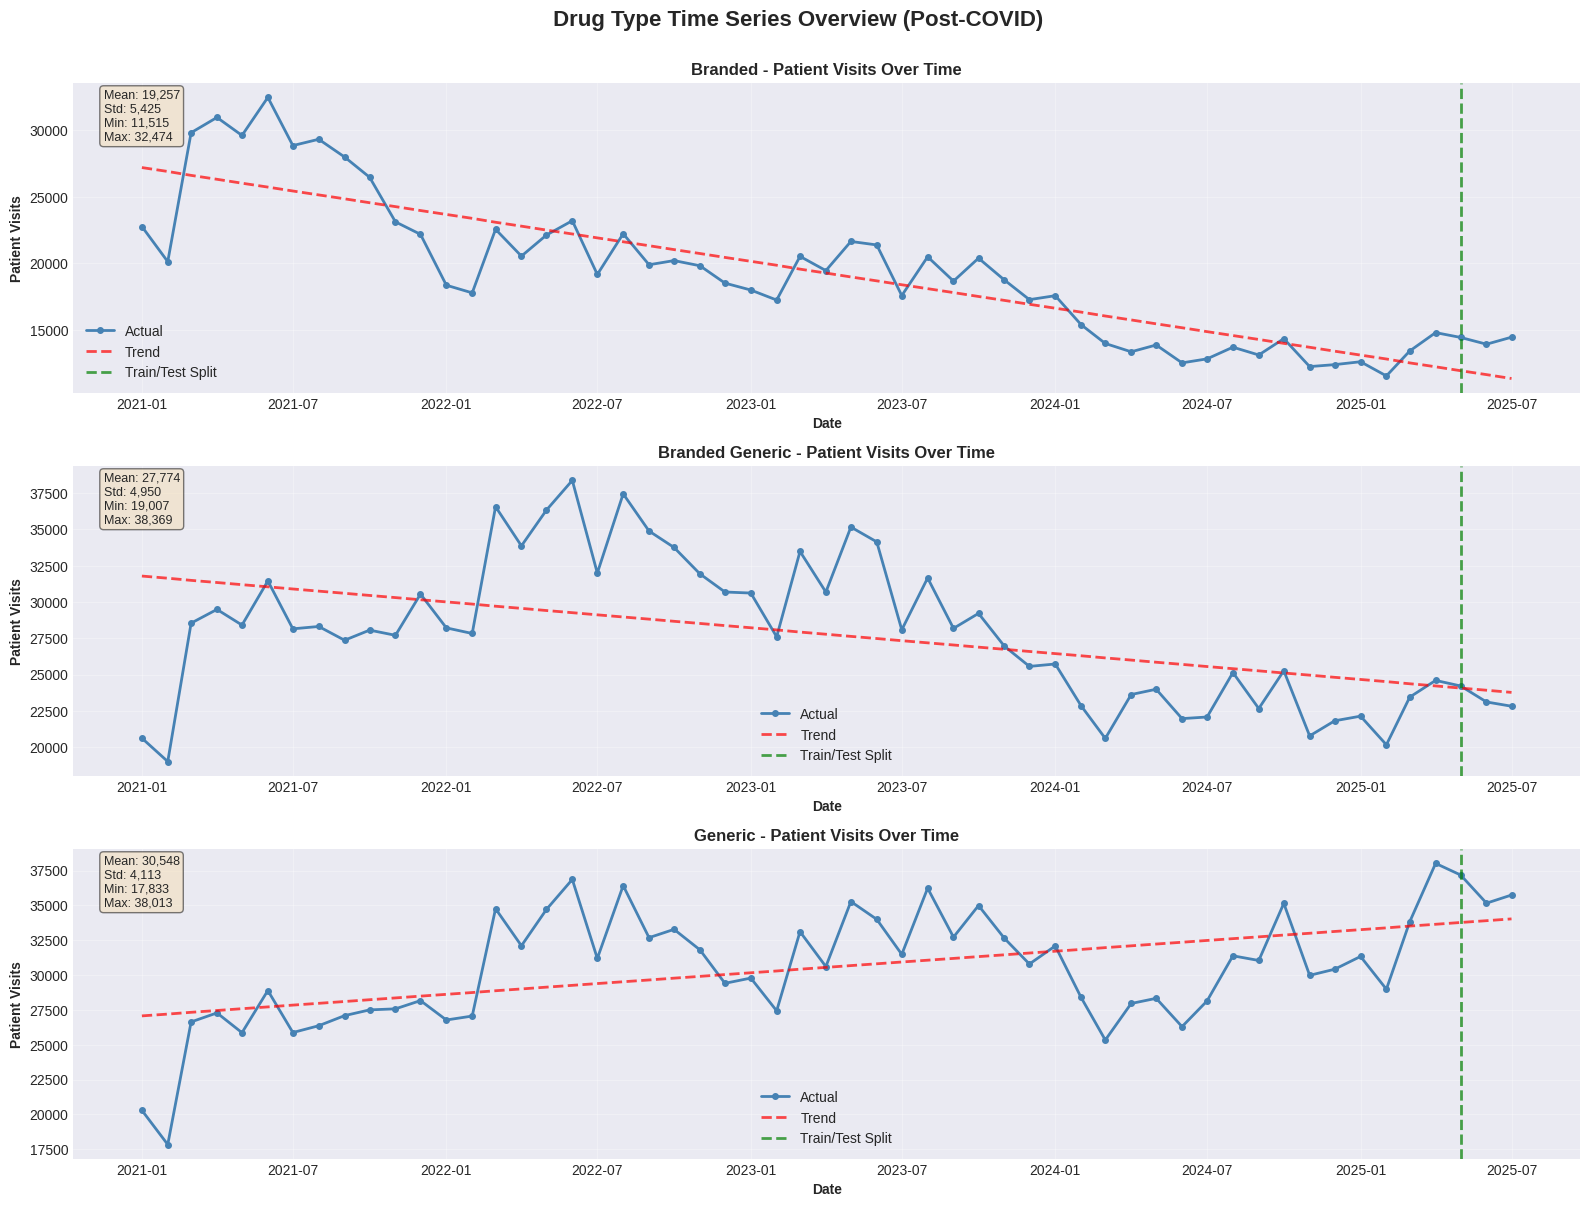

In [24]:
# Visualizations
print("Visualizations")
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. TIME SERIES OVERVIEW
print("\n Time Series Overview")

fig, axes = plt.subplots(len(ts_data.columns), 1, figsize=(16, 4*len(ts_data.columns)))
if len(ts_data.columns) == 1:
    axes = [axes]

fig.suptitle(' Drug Type Time Series Overview (Post-COVID)', fontsize=16, fontweight='bold', y=1.002)

for idx, col in enumerate(ts_data.columns):
    ax = axes[idx]
    series = ts_data[col]

    ax.plot(series.index, series.values, marker='o', linewidth=2, markersize=4, label='Actual', color='steelblue')

    # Trend line
    z = np.polyfit(range(len(series)), series.values, 1)
    p = np.poly1d(z)
    ax.plot(series.index, p(range(len(series))), "--", linewidth=2, color='red', alpha=0.7, label='Trend')

    # Train/test split
    split_point = series.index[-TEST_MONTHS]
    ax.axvline(x=split_point, color='green', linestyle='--', linewidth=2, label='Train/Test Split', alpha=0.7)

    ax.set_title(f'{col} - Patient Visits Over Time', fontweight='bold', fontsize=12)
    ax.set_xlabel('Date', fontweight='bold')
    ax.set_ylabel('Patient Visits', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

    stats_text = f"Mean: {series.mean():,.0f}\nStd: {series.std():,.0f}\nMin: {series.min():,.0f}\nMax: {series.max():,.0f}"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

Stationarity Test Results 


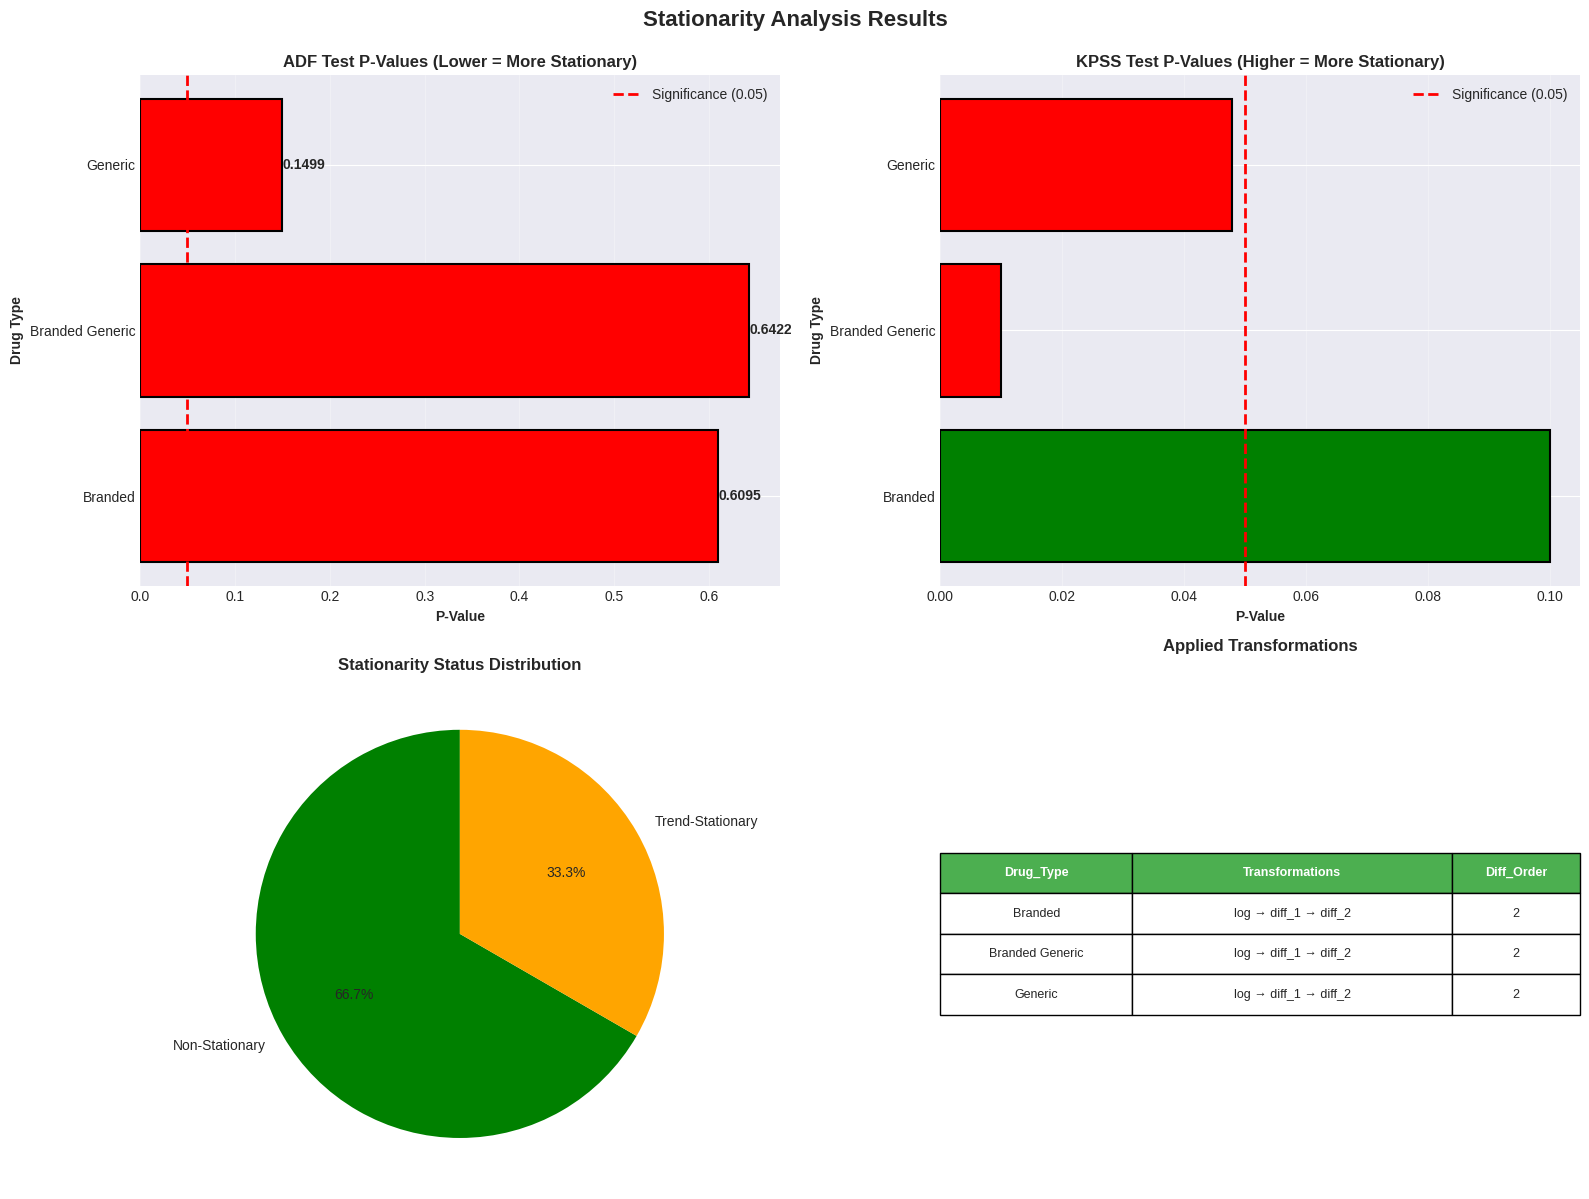

In [25]:
# 2. Stationarity Test
print("Stationarity Test Results ")
if len(stationarity_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Stationarity Analysis Results', fontsize=16, fontweight='bold', y=0.995)

    # ADF p-values
    ax1 = axes[0, 0]
    colors_adf = ['green' if p < 0.05 else 'red' for p in stationarity_df['ADF_PValue']]
    bars = ax1.barh(stationarity_df['Drug_Type'], stationarity_df['ADF_PValue'], color=colors_adf, edgecolor='black', linewidth=1.5)
    ax1.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Significance (0.05)')
    ax1.set_title('ADF Test P-Values (Lower = More Stationary)', fontweight='bold')
    ax1.set_xlabel('P-Value', fontweight='bold')
    ax1.set_ylabel('Drug Type', fontweight='bold')
    ax1.legend()
    ax1.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, stationarity_df['ADF_PValue']):
        ax1.text(val, bar.get_y() + bar.get_height()/2, f'{val:.4f}', ha='left', va='center', fontweight='bold')

    # KPSS p-values
    ax2 = axes[0, 1]
    colors_kpss = ['green' if p > 0.05 else 'red' for p in stationarity_df['KPSS_PValue']]
    bars = ax2.barh(stationarity_df['Drug_Type'], stationarity_df['KPSS_PValue'], color=colors_kpss, edgecolor='black', linewidth=1.5)
    ax2.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Significance (0.05)')
    ax2.set_title('KPSS Test P-Values (Higher = More Stationary)', fontweight='bold')
    ax2.set_xlabel('P-Value', fontweight='bold')
    ax2.set_ylabel('Drug Type', fontweight='bold')
    ax2.legend()
    ax2.grid(axis='x', alpha=0.3)

    # Stationarity conclusion
    ax3 = axes[1, 0]
    conclusion_counts = stationarity_df['Conclusion'].value_counts()
    colors_conclusion = ['green', 'orange', 'red']
    ax3.pie(conclusion_counts.values, labels=conclusion_counts.index, autopct='%1.1f%%', colors=colors_conclusion, startangle=90)
    ax3.set_title('Stationarity Status Distribution', fontweight='bold')

    # Transformation summary
    ax4 = axes[1, 1]
    transform_data = []
    for drug_type in transformed_series.keys():
        transforms = transformed_series[drug_type]['transformations']
        transform_data.append({
            'Drug_Type': drug_type,
            'Transformations': ' → '.join(transforms),
            'Diff_Order': transformed_series[drug_type]['diff_order']
        })
    transform_df = pd.DataFrame(transform_data)

    ax4.axis('tight')
    ax4.axis('off')
    table = ax4.table(cellText=transform_df.values, colLabels=transform_df.columns,
                     cellLoc='center', loc='center', colWidths=[0.3, 0.5, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    for i in range(len(transform_df.columns)):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    ax4.set_title('Applied Transformations', fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()



 Forecast Results (SARIMA, Prophet, Exponential Smoothing)


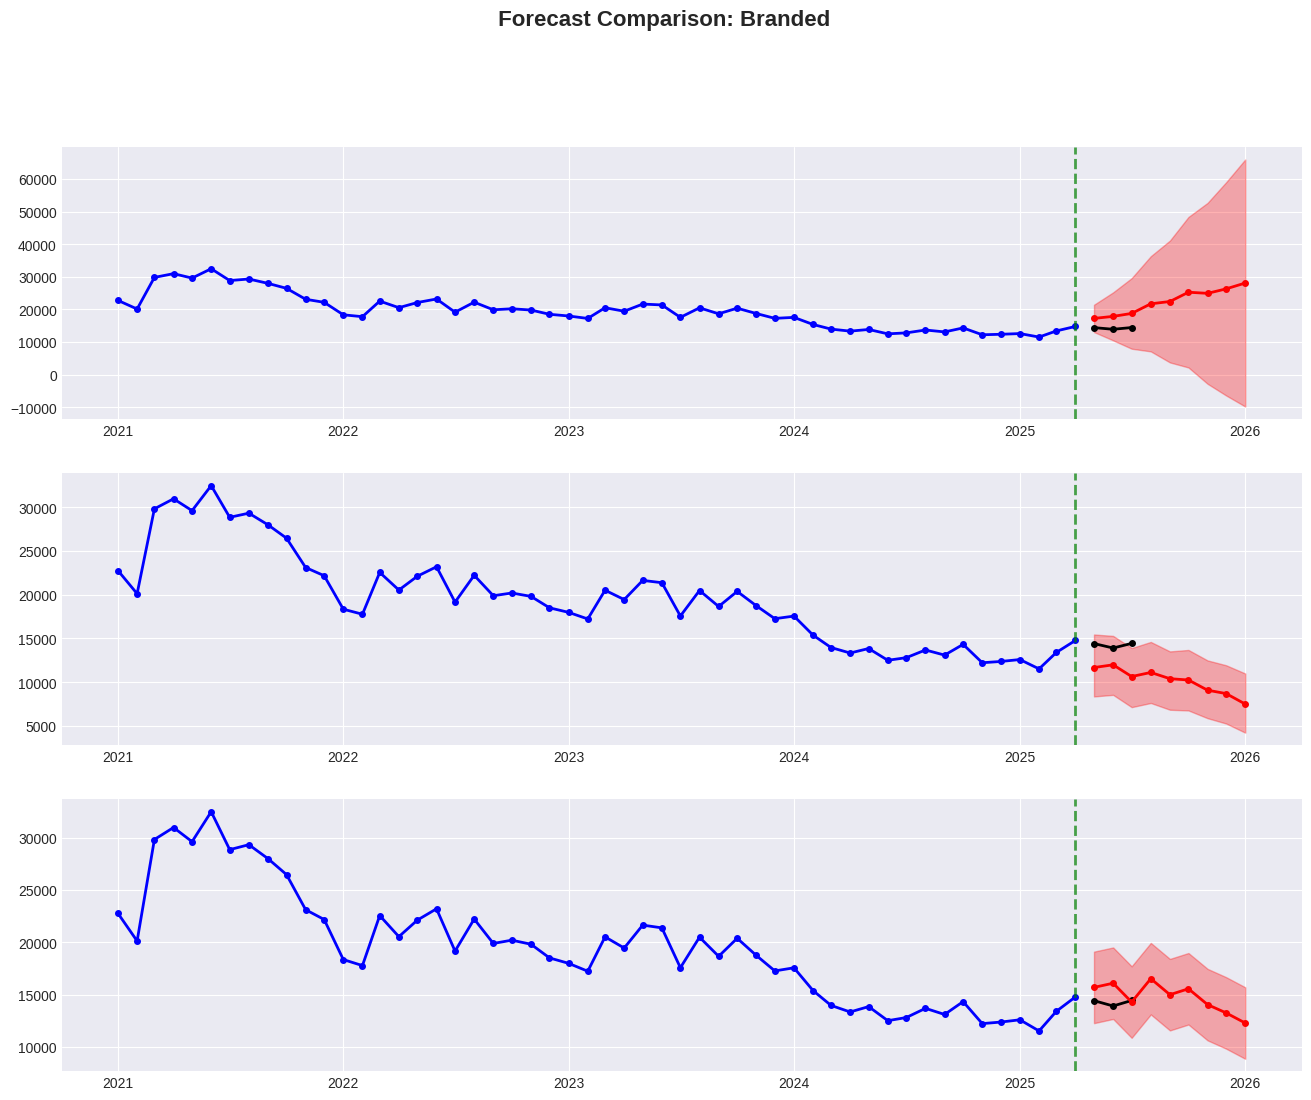

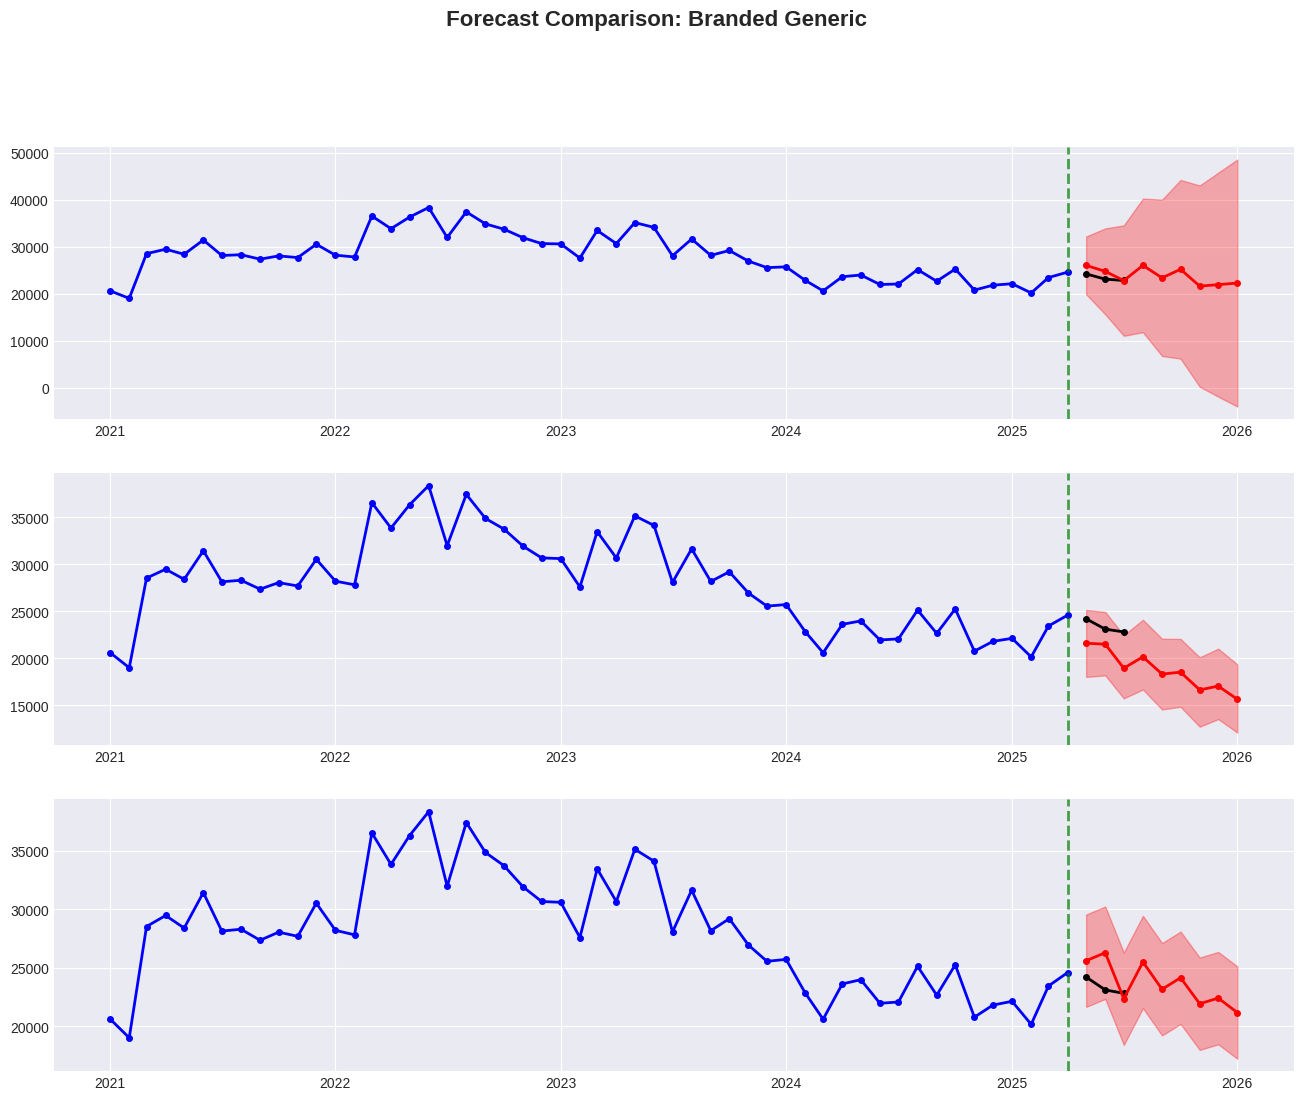

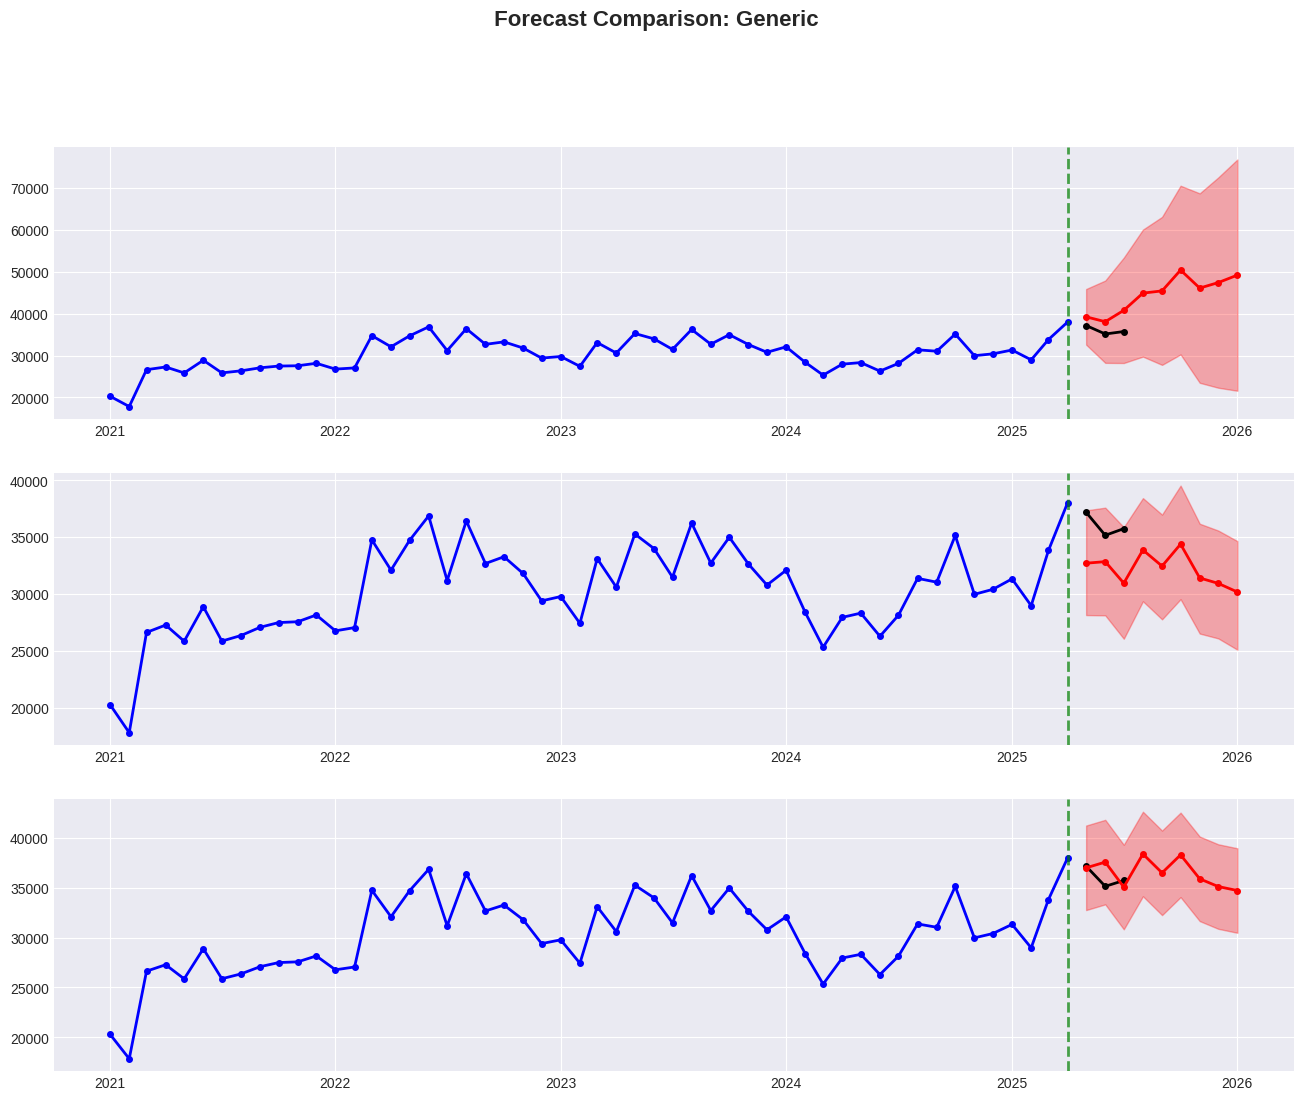

In [26]:
#Forecast Comparision
print("\n Forecast Results (SARIMA, Prophet, Exponential Smoothing)")
for drug_type, data in forecast_data.items():
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    fig.suptitle(f' Forecast Comparison: {drug_type}', fontsize=16, fontweight='bold', y=0.995)

    train = data['train']
    test = data['test']

    last_date = train.index[-1]
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=FORECAST_HORIZON, freq='MS')

    models = ['sarima', 'prophet', 'exp_smoothing']
    model_names = ['SARIMA', 'Prophet', 'Exponential Smoothing']

    for idx, (model_key, model_name) in enumerate(zip(models, model_names)):
        ax = axes[idx]
        model_result = data[model_key]

        if model_result is None:
            ax.text(0.5, 0.5, f'{model_name} - Failed to converge', ha='center', va='center', fontsize=14, transform=ax.transAxes)
            continue

        ax.plot(train.index, train.values, 'o-', linewidth=2, markersize=4, label='Training Data', color='blue')
        ax.plot(test.index, test.values, 'o-', linewidth=2, markersize=4, label='Actual Test Data', color='black')
        ax.plot(future_dates, model_result['forecast'], 'o-', linewidth=2, markersize=4, label='Forecast', color='red')
        ax.fill_between(future_dates, model_result['lower'], model_result['upper'], alpha=0.3, color='red', label='95% Confidence Interval')
        ax.axvline(x=train.index[-1], color='green', linestyle='--', linewidth=2, label='Forecast Start',alpha = 0.7)


In [27]:
#Forecast Comparision Plots (For each drug type)
ax.set_title(f'{model_name} - MAPE: {model_result["mape"]:.2f}%', fontweight='bold', fontsize=12)
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Patient Visits', fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

last_actual = train.iloc[-1]
forecast_avg = np.mean(model_result['forecast'][:6])
growth = ((forecast_avg - last_actual) / last_actual) * 100
growth_text = f"6-Month Avg Growth: {growth:+.1f}%"

ax.text(
    0.02, 0.98, growth_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    fontweight='bold',
    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7)
)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>


 Model Performance Comparison 


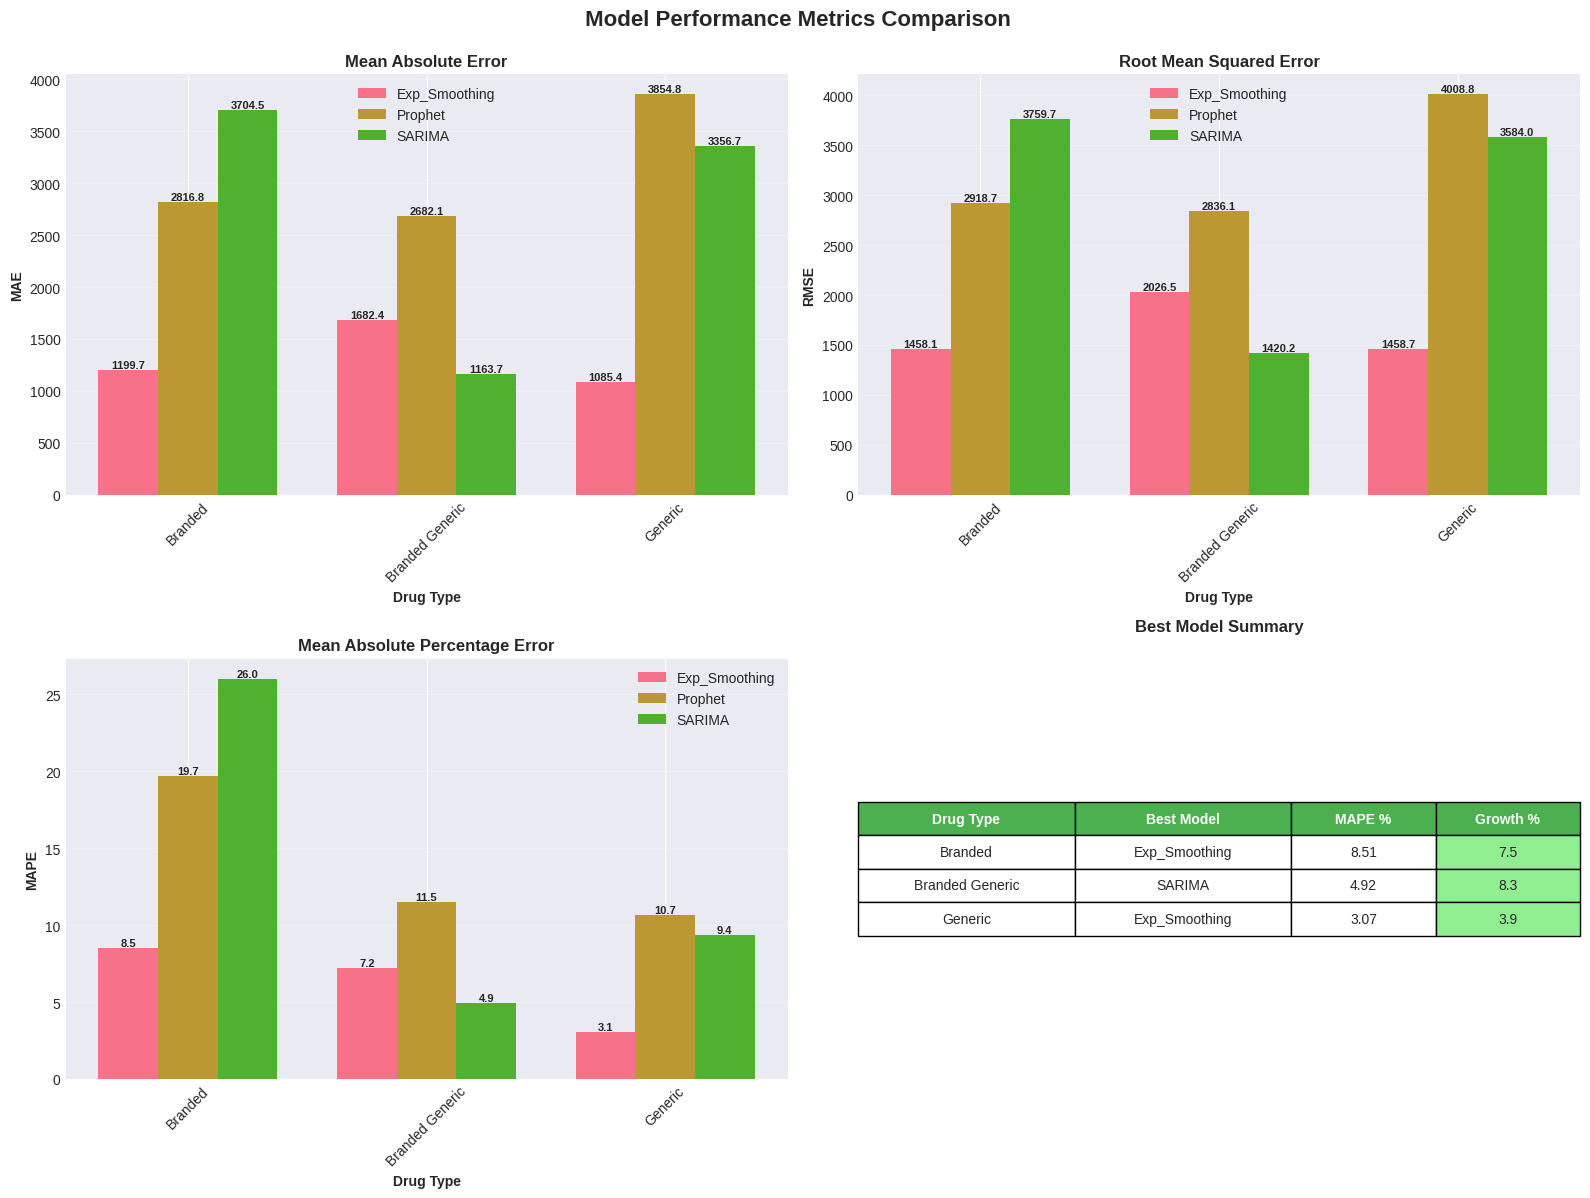

In [28]:
# Model Performance Comparision
print("\n Model Performance Comparison ")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(' Model Performance Metrics Comparison', fontsize=16, fontweight='bold', y=0.995)

metrics = ['MAE', 'RMSE', 'MAPE']
metric_titles = ['Mean Absolute Error', 'Root Mean Squared Error', 'Mean Absolute Percentage Error']

for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
    ax = axes[idx // 2, idx % 2]
    pivot_data = results_df.pivot(index='Drug_Type', columns='Model', values=metric)

    x = np.arange(len(pivot_data.index))
    width = 0.25

    for i, model in enumerate(pivot_data.columns):
        offset = (i - len(pivot_data.columns)/2 + 0.5) * width
        bars = ax.bar(x + offset, pivot_data[model], width, label=model)

        for bar in bars:
            height = bar.get_height()
            if not np.isnan(height):
                ax.text(
                    bar.get_x() + bar.get_width()/2.,
                    height,
                    f'{height:.1f}',
                    ha='center',
                    va='bottom',
                    fontsize=8,
                    fontweight='bold'
                )

    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_xlabel('Drug Type', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_data.index, rotation=45)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Best Model Summary Table
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')

display_df = best_df[['Drug_Type', 'Best_Model', 'MAPE_%', 'Growth_%']].copy()
display_df.columns = ['Drug Type', 'Best Model', 'MAPE %', 'Growth %']
display_df['MAPE %'] = display_df['MAPE %'].round(2)
display_df['Growth %'] = display_df['Growth %'].round(1)

table = ax4.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    colWidths=[0.3, 0.3, 0.2, 0.2]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(len(display_df.columns)):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, len(display_df) + 1):
    growth_val = float(display_df.iloc[i-1]['Growth %'])
    color = '#90EE90' if growth_val > 0 else '#FFB6C6'
    table[(i, 3)].set_facecolor(color)

ax4.set_title('Best Model Summary', fontweight='bold', fontsize=12, pad=20)

plt.tight_layout()
plt.show()


 Growth Projections 


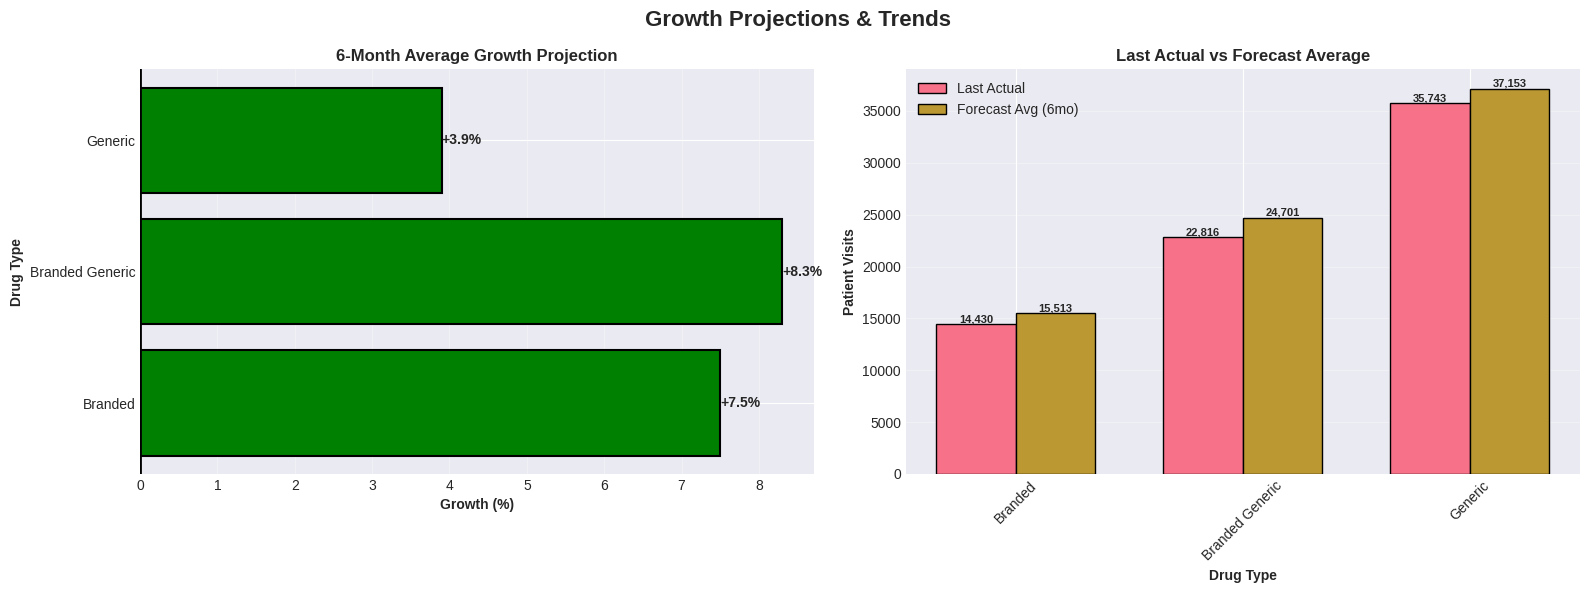

In [29]:
print("\n Growth Projections ")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(' Growth Projections & Trends', fontsize=16, fontweight='bold')

# Growth Comparison
ax1 = axes[0]
colors = ['green' if g > 0 else 'red' for g in best_df['Growth_%']]
bars = ax1.barh(
    best_df['Drug_Type'],
    best_df['Growth_%'],
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

ax1.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax1.set_title('6-Month Average Growth Projection', fontweight='bold')
ax1.set_xlabel('Growth (%)', fontweight='bold')
ax1.set_ylabel('Drug Type', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, best_df['Growth_%']):
    ax1.text(
        val,
        bar.get_y() + bar.get_height()/2,
        f'{val:+.1f}%',
        ha='left' if val > 0 else 'right',
        va='center',
        fontweight='bold',
        fontsize=10
    )

# Forecast vs Last Actual
ax2 = axes[1]
x = np.arange(len(best_df))
width = 0.35

bars1 = ax2.bar(
    x - width/2,
    best_df['Last_Actual'],
    width,
    label='Last Actual',
    edgecolor='black'
)

bars2 = ax2.bar(
    x + width/2,
    best_df['Forecast_Avg'],
    width,
    label='Forecast Avg (6mo)',
    edgecolor='black'
)

ax2.set_title('Last Actual vs Forecast Average', fontweight='bold')
ax2.set_ylabel('Patient Visits', fontweight='bold')
ax2.set_xlabel('Drug Type', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(best_df['Drug_Type'], rotation=45)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(
            bar.get_x() + bar.get_width()/2.,
            height,
            f'{int(height):,}',
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()

